In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [101]:
X = pd.read_csv(
    "market_features_weekly_std.csv",
    parse_dates=["Date"],
    index_col="Date"
)

In [102]:
print(X.head())

            SP500_Return       VIX  Yield_Spread
Date                                            
1994-01-14      0.377339 -1.044307      0.656456
1994-01-21     -0.077835 -1.051667      0.689011
1994-01-28      0.284015 -1.192727      0.645604
1994-02-04     -0.836581 -0.541398      0.558790
1994-02-11     -0.028727 -0.638300      0.471976


In [103]:
np.isnan(X.values).sum()
np.isinf(X.values).sum()

np.int64(0)

In [104]:
#Double checking for error prevention
print("NaNs:", np.isnan(X.values).sum())
print("Infs:", np.isinf(X.values).sum())
print("Min:", X.min())
print("Max:", X.max())

NaNs: 0
Infs: 0
Min: SP500_Return   -8.367609
VIX            -1.290855
Yield_Spread   -2.240967
dtype: float64
Max: SP500_Return    4.663367
VIX             7.294174
Yield_Spread    2.067186
dtype: float64


In [105]:
print(X.shape)
print(np.linalg.matrix_rank(X.values))

(1564, 3)
3


In [106]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    init_params="k-means++",
    n_init=10,
    random_state=42
)

gmm.fit(X)

/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nick/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sa

GaussianMixture(init_params='k-means++', n_components=3, n_init=10,
                random_state=42)

In [107]:
labels = gmm.predict(X)

np.bincount(labels)

array([461, 900, 203])

In [108]:
regimes_gmm = X.copy()
regimes_gmm["Regime_GMM"] = labels


In [109]:
label_map = {
    0: "Stressful",
    1: "Calm",
    2: "Transitional"
}

regimes_gmm["Regime_label"] = regimes_gmm["Regime_GMM"].map(label_map)

#I am assigning labels for better interpretability of the data and statistics

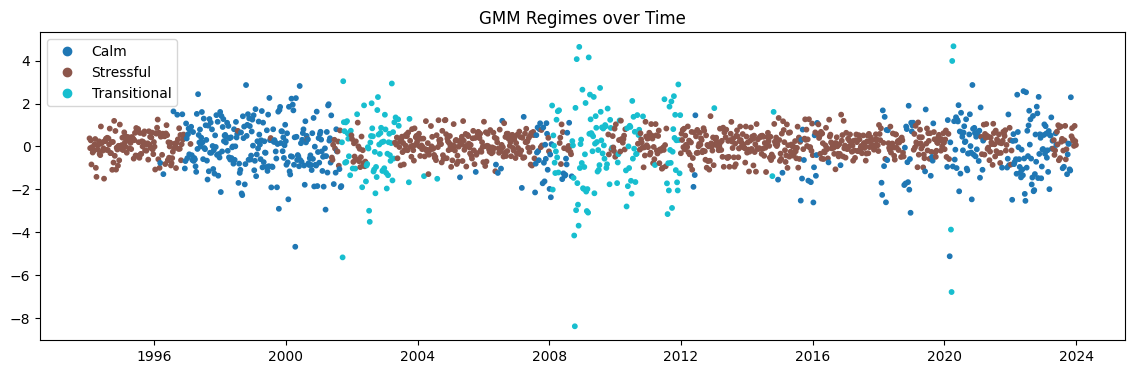

In [110]:
plt.figure(figsize=(14,4))
sc = plt.scatter(
    regimes_gmm.index,
    regimes_gmm["SP500_Return"],
    c=regimes_gmm["Regime_GMM"],
    cmap="tab10",
    s=10
)
plt.title("GMM Regimes over Time")
handles, _ = sc.legend_elements()
plt.legend(handles, regimes_gmm["Regime_label"].unique())
plt.show()

In [111]:
regime_stats = regimes_gmm.groupby("Regime_label").agg({
    "SP500_Return": ["mean", "std"],
    "VIX": ["mean", "std"],
    "Yield_Spread": ["mean", "std"]
})

In [112]:
def avg_duration(labels):
    runs = np.diff(np.where(np.diff(labels) != 0)[0])
    return runs.mean()

avg_duration(labels)

np.float64(8.395348837209303)

In [113]:
print(regime_stats)

             SP500_Return                 VIX           Yield_Spread          
                     mean       std      mean       std         mean       std
Regime_label                                                                  
Calm             0.084711  0.513487 -0.593623  0.369421     0.135306  0.950990
Stressful       -0.113450  1.190242  0.502281  0.617895    -0.780874  0.548056
Transitional    -0.117930  1.807678  1.491176  1.373082     1.173439  0.420349


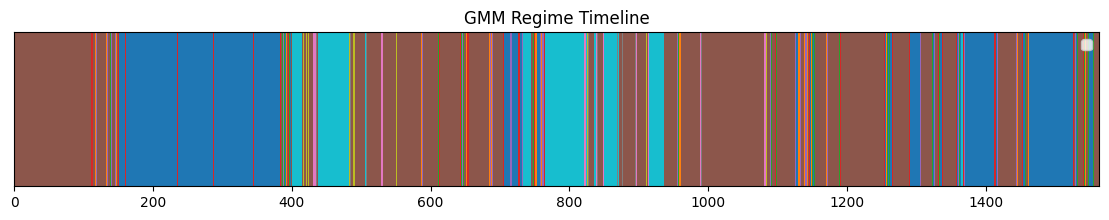

In [114]:
plt.figure(figsize=(14,2))
plt.imshow(regimes_gmm["Regime_GMM"].values.reshape(1, -1),
           aspect="auto",
           cmap="tab10")
plt.yticks([])
plt.title("GMM Regime Timeline")
plt.legend(regimes_gmm["Regime_label"])
plt.show()

In [115]:
#This number shows that average regime duration for this model is 6.6 weeks

In [116]:
#Based on that we can make the following conclusion: static clustering identifies short-lived market states rather than persistent regimes.

In [117]:
#To conclude this notebook, we get 3 regime types. Let's label them calm, transitional and volatile.